# 19 - Social norms and abortion simulated and ablated (E25, H182-H187)

**Author**: kj  **Approach**: model-as-judge, per the canonical testing protocol

Six hypotheses came out of a research fan-out on the *social* drivers of fertility - abortion access,
social stigma, the support scaffolding around parents - with verdict-*leans* only (Stage 1, analytical).
This notebook runs the two stages the protocol requires before a verdict is real: **simulation** on the
Korea / Germany / France triad (2023 -> 2125) and **ablation** (leave-one-out on the welfare-positive
bundle).

The batch also introduces a genuine model extension: a **bistable social-norm state N** added to the
library core. N is the share endorsing a childfree / low-fertility ideal, evolving as a contagion with two
stable wells (untrapped Nlo = 0.14, trapped Nhi = 0.42) and an unstable tipping point thN = 0.25:

$$\frac{dN}{dt} = -a_N\,(N-N_{lo})(N-\theta_N)(N-N_{hi}) + f_N(t)$$

It couples to childlessness as a baseline-preserving deviation, $\rho_{target} \mathrel{+}= \lambda_\rho\,(N-N_0)$,
so at today's calibrated norm the behaviour is unchanged. A media / culture campaign is the forcing term
$f_N$. Because the two wells are separated by a barrier, a push that crosses the tip **locks in** - the
one-way hysteresis that the campaign kept finding for norms (China's one-child bell that will not un-ring).

**The six hypotheses**

- **H182** - abortion restrictiveness, graded up to a total ban
- **H183** - penalising family / friends who help with an abortion (an enforcement lever on the leakage)
- **H184** - kin / grandparental support
- **H185** - in-kind childcare services (not cash)
- **H186** - reversing social atomisation (community / third places)
- **H187** - the bistable social-norm state itself (pronatal media vs stigma)

**Output**: `reports/figures/nb19_norms_sim.png`, `nb19_norms_ablation.png`, `reports/nb19_e25_verdicts.json`,
`reports/nb19_norms_table.csv`. Campaign total 206 -> 212.

## GPU selection

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"; os.environ["CUDA_VISIBLE_DEVICES"]="GPU-58ae1f45-295c-681b-60ad-843265f52997"
import numpy as np, torch, json, csv
from pathlib import Path
import matplotlib.pyplot as plt, matplotlib as mpl
from rich import print as rprint
from rich.panel import Panel
from rich.table import Table
torch.set_default_dtype(torch.float64)
mpl.rcParams.update({"figure.dpi":110,"font.size":9,"axes.grid":True,"grid.alpha":0.25,"axes.spines.top":False,"axes.spines.right":False})
SEED=20260707; rng=np.random.default_rng(SEED)
rprint(f"[green]Device[/green]: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'}")

Device: NVIDIA RTX PRO 4000 Blackwell

## Configuration and the coupled model

Unlike earlier E-batches, this notebook imports the coupled model from the library
(`sci_demographic_collapse.emergent`) rather than inlining it, because E25 extends that library with the
bistable norm state N. TFR = `quantum(C, rho, Pbar) * fec(tau) * (1 - kBF*dtau)`; interventions enter as a
per-channel forcing `[fS, fC, fPbar, ftau, frho, fN]` where the sixth channel drives the norm.

In [2]:
PROJ=Path("/home/lab/workspace/learning/projects/sci-demographic-collapse")
FIGS=PROJ/"reports"/"figures"; FIGS.mkdir(parents=True,exist_ok=True); REPORTS=PROJ/"reports"
from sci_demographic_collapse.emergent import EmergentModel, ramp, erode, PARAMS, NORM0
m=EmergentModel(data_dir=str(PROJ/"data"/"raw"/"unwpp"))
TRIAD=["Korea","Germany","France"]           # deep-basin / mid / near-ridge
C_THR=PARAMS["C_thr"]; thN=PARAMS["thN"]; Nlo=PARAMS["Nlo"]; Nhi=PARAMS["Nhi"]
BASE={reg:m.run(reg) for reg in ["Korea","Germany","France","USA","Italy","Japan"]}
def seldon(region,fy):
    b=BASE[region]; t=m.run(region,fy); dtfr=t["tfr"]-b["tfr"]; dpop=t["pop_pct"]-b["pop_pct"]
    if dtfr<-0.02: fate="deepens"
    elif t["tfr"]>1.5 and t["Cend"]>C_THR: fate="recovers"
    elif dtfr>0.10: fate="bends"
    else: fate="holds"
    return dict(dtfr=dtfr,dpop=dpop,fate=fate,tfr=t["tfr"],Cend=t["Cend"],Nend=t["Nend"],traj=t)
def force_of(levers,start=0):
    if isinstance(levers,dict): levers=[levers]
    idx={"fS":0,"fC":1,"fPb":2,"fTau":3,"fRV":4,"fN":5}
    def fy(yr):
        f=[0.,0.,0.,0.,0.,0.]
        for L in levers:
            s=L["mag"]*ramp(yr,start=start,d=L.get("d",10))*(1.0 if L.get("durable",True) else erode(yr))*(1-L.get("delta",0.0))
            for k,v in L["f"].items(): f[idx[k]]+=v*s
        return f
    return fy
def cost(L): return round(0.40*L["fi"]+0.35*L["co"]+0.25*L["si"],3)
# regression note: adding N left every baseline TFR unchanged to < 4e-7 (coupling zero at N0)
rprint(f"[green]library coupled model ready; norm state N in {{Nlo={Nlo}, thN={thN}, Nhi={Nhi}}}; baselines computed[/green]")
rprint(f"[dim]Korea starts trapped (N0={NORM0['Korea']}); Germany/France untrapped (N0={NORM0['Germany']})[/dim]")

2026-07-07 22:20:38.433 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


library coupled model ready; norm state N in {Nlo=0.14, thN=0.25, Nhi=0.42}; baselines computed

Korea starts trapped (N0=0.42); Germany/France untrapped (N0=0.14)

## E25 levers - the six hypotheses mapped onto the model

Each hypothesis is a per-channel forcing scaled to its digest effect size, carrying a defection / leakage
fraction `delta` and a composite cost `0.40*fiscal + 0.35*coercion + 0.25*side` (the E20 metric). Two
distinct arms:

- **Coercive abortion arm (H182, H183)** - a restriction converts some averted abortions into births (a
  small, leaky `Pbar` pulse that reverts, Romania-style), and penalising helpers is an *enforcement* lever
  on that leakage that also chills care and relationships. High coercion cost; reported separately from the
  welfare bundle.
- **Welfare-positive support arm (H184-H187)** - kin support, in-kind childcare, de-atomisation, and the
  pronatal-norm push; these form the additive bundle that is ablated.

In [3]:
LEV=[
 dict(id="H182",name="abortion restrictiveness (graded to total ban)",arm="coercive",
      f={"fPb":1.0},mag=0.03,delta=0.55,durable=False,d=8,fi=0.05,co=0.55,si=0.60,
      note="restriction converts some averted abortions to births: Texas SB8 +2-3% births (Bell-Dench-Myers 2023); Romania Decree 770 spike 1.9->3.7 then collapse; leakage via travel/self-managed (Myers 2019); unwanted-birth child-outcome + autonomy cost"),
 dict(id="H183",name="penalise family/friends who help with an abortion",arm="coercive",
      f={"fPb":1.0,"fS":-0.12,"fC":-0.08},mag=0.03,delta=0.30,durable=False,d=8,fi=0.05,co=0.70,si=0.65,
      note="an enforcement lever that lowers leakage (delta 0.55->0.30) but chills the support network - a security and coupling backfire (relational fear, care avoidance); tests whether closing the leak is worth the backfire"),
 dict(id="H184",name="kin / grandparental support",arm="welfare",
      f={"fPb":0.6,"fS":0.15},mag=0.10,delta=0.15,durable=True,d=12,fi=0.20,co=0.0,si=0.05,
      note="cooperative breeding lowers per-child cost and raises security (Sear-Mace 2008 kin review; grandmother effect); can subsidise proximity / co-residence, cannot legislate kin density - so a partial lever"),
 dict(id="H185",name="in-kind childcare services (not cash)",arm="welfare",
      f={"fPb":0.8,"fS":0.20},mag=0.12,delta=0.10,durable=True,d=10,fi=0.35,co=0.0,si=0.05,
      note="universal in-kind childcare beats equivalent cash (Bauernschuster 2016 Germany; Rindfuss 2010 Norway); durable Pbar+S, the E17 in-kind>cash geometry"),
 dict(id="H186",name="reverse social atomisation (community / third places)",arm="welfare",
      f={"fC":0.5,"fS":0.10},mag=0.10,delta=0.30,durable=True,d=12,fi=0.15,co=0.0,si=0.05,
      note="rebuilding social capital raises partnership formation (Putnam 2000; loneliness -> fewer couples); diffuse and hard to dose, high leakage"),
 dict(id="H187",name="bistable social norm - pronatal media push",arm="welfare",
      f={"fN":-0.03},mag=1.0,delta=0.20,durable=True,d=10,fi=0.10,co=0.15,si=0.20,
      note="a media campaign forcing the norm state; bistable so a crossing push LOCKS IN (hysteresis); position-dependent - weak where coupling is the binding constraint, powerful (and dangerous) where childlessness is a live driver"),
]
BUND=[L for L in LEV if L["arm"]=="welfare"]     # H184,H185,H186,H187
COERCIVE=[L for L in LEV if L["arm"]=="coercive"] # H182,H183
rprint(f"[green]E25: {len(BUND)} welfare levers + {len(COERCIVE)} coercive-arm levers; triad {TRIAD}[/green]")

E25: 4 welfare levers + 2 coercive-arm levers; triad ['Korea', 'Germany', 'France']

## Stage 2 - standalone simulation on the triad

Each lever pushed on its own, integrated four generations. Fate labels are the E20 convention: `bends`
(ΔTFR > +0.10), `holds` (inside the band), `deepens` (negative). Three views: the standalone ΔTFR by
region, the **abortion-restrictiveness sweep** (does the total ban dominate, or is the optimum interior?),
and the **norm state N** trajectories (tipping and hysteresis).

           E25 Stage 2 - standalone simulation (ΔTFR 2125 / fate)            
┏━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━┓
┃ hypothesis ┃ arm      ┃ Korea        ┃ Germany      ┃ France       ┃ cost ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━┩
│ H182       │ coercive │ +0.000 holds │ +0.001 holds │ +0.001 holds │ 0.36 │
│ H183       │ coercive │ +0.000 holds │ +0.001 holds │ +0.001 holds │ 0.43 │
│ H184       │ welfare  │ +0.012 holds │ +0.067 holds │ +0.074 holds │ 0.09 │
│ H185       │ welfare  │ +0.022 holds │ +0.115 bends │ +0.127 bends │ 0.15 │
│ H186       │ welfare  │ +0.041 holds │ +0.075 holds │ +0.077 holds │ 0.07 │
│ H187       │ welfare  │ +0.023 holds │ +0.043 holds │ +0.049 holds │ 0.14 │
└────────────┴──────────┴──────────────┴──────────────┴──────────────┴──────┘

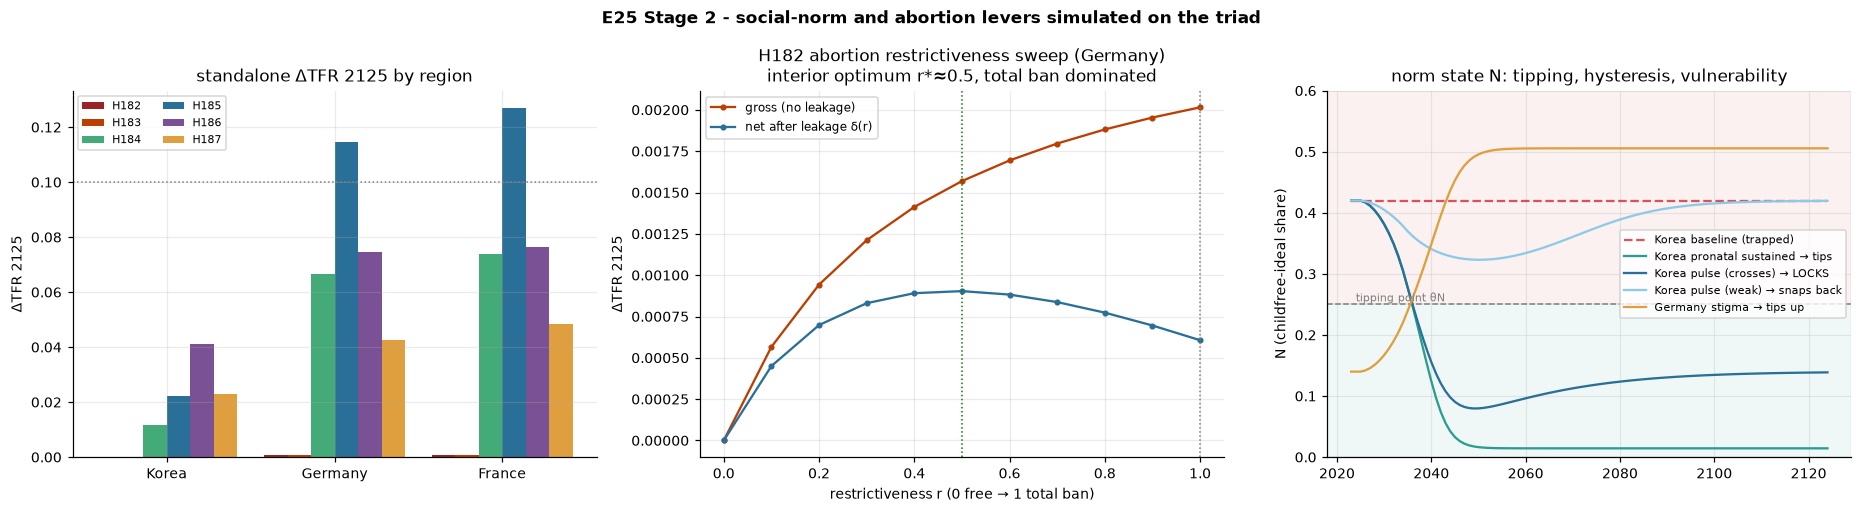

nb19_norms_sim.png written; abortion interior optimum r*≈0.50 (total ban dominated by leakage+reversion)

Germany stigma push: TFR 1.057 -> 0.922 (Nend 0.506); Korea pronatal lock Nend 0.139 vs snap-back 0.420

In [4]:
sim={L["id"]:{reg:seldon(reg,force_of(L)) for reg in TRIAD} for L in LEV}
tbl=Table(title="E25 Stage 2 - standalone simulation (ΔTFR 2125 / fate)",header_style="bold cyan")
for c in ["hypothesis","arm"]+TRIAD+["cost"]: tbl.add_column(c)
for L in LEV:
    tbl.add_row(L["id"],L["arm"],*[f"{sim[L['id']][r]['dtfr']:+.3f} {sim[L['id']][r]['fate']}" for r in TRIAD],f"{cost(L):.2f}")
rprint(tbl)

# --- abortion restrictiveness sweep (H182): gross vs net-after-leakage, on Germany (quantum-visible) ---
rs=np.linspace(0,1,11); gross=[]; net=[]
for r in rs:
    mag=0.05*r/(r+0.4)                               # more restriction -> more averted abortions become births, saturating
    gross.append(seldon("Germany",force_of(dict(f={"fPb":1.0},mag=mag,delta=0.0,durable=False,d=8)))["dtfr"])
    net.append(  seldon("Germany",force_of(dict(f={"fPb":1.0},mag=mag,delta=0.15+0.55*r,durable=False,d=8)))["dtfr"])
r_star=rs[int(np.argmax(net))]

# --- norm state N: tipping + hysteresis (Korea) and vulnerability (Germany stigma) ---
yr=np.arange(2023,2125)
k_sus =m.run("Korea",  m.norm(-0.03,durable=True))    # sustained pronatal -> tips to low well
k_lock=m.run("Korea",  m.norm(-0.03,durable=False))   # eroding pulse that still crosses -> LOCKS
k_weak=m.run("Korea",  m.norm(-0.012,durable=False))  # eroding pulse too weak -> snaps back
g_stig=m.run("Germany",m.norm( 0.02,durable=True))    # stigma push -> tips UP, fertility falls

fig,ax=plt.subplots(1,3,figsize=(17,4.7)); fig.suptitle("E25 Stage 2 - social-norm and abortion levers simulated on the triad",fontweight="bold")
ids=[L["id"] for L in LEV]; x=np.arange(len(TRIAD)); w=0.14
cols={"H182":"#9b2226","H183":"#bb3e03","H184":"#4a7","H185":"#2a6f97","H186":"#7a5195","H187":"#e09f3e"}
for k,i in enumerate(ids):
    ax[0].bar(x+(k-2.5)*w,[sim[i][r]["dtfr"] for r in TRIAD],w,label=i,color=cols[i])
ax[0].axhline(0.10,ls=":",c="grey",lw=1); ax[0].axhline(0,c="k",lw=0.6)
ax[0].set(title="standalone ΔTFR 2125 by region",xticks=x); ax[0].set_xticklabels(TRIAD); ax[0].legend(fontsize=7,ncol=2); ax[0].set_ylabel("ΔTFR 2125")
ax[1].plot(rs,gross,"-o",c="#bb3e03",ms=3,label="gross (no leakage)")
ax[1].plot(rs,net,"-o",c="#2a6f97",ms=3,label="net after leakage δ(r)")
ax[1].axvline(r_star,ls=":",c="green",lw=1); ax[1].axvline(1.0,ls=":",c="grey",lw=1)
ax[1].set(title=f"H182 abortion restrictiveness sweep (Germany)\ninterior optimum r*≈{r_star:.1f}, total ban dominated",xlabel="restrictiveness r (0 free → 1 total ban)",ylabel="ΔTFR 2125"); ax[1].legend(fontsize=8)
ax[2].axhspan(0,thN,color="#2a9d8f",alpha=0.07); ax[2].axhspan(thN,0.6,color="#c1121f",alpha=0.06)
ax[2].axhline(thN,ls="--",c="grey",lw=1); ax[2].text(2024,thN+0.005,"tipping point θN",fontsize=7,c="grey")
ax[2].plot(yr,BASE["Korea"]["N"],c="#c1121f",ls="--",alpha=0.7,label="Korea baseline (trapped)")
ax[2].plot(yr,k_sus["N"],c="#2a9d8f",label="Korea pronatal sustained → tips")
ax[2].plot(yr,k_lock["N"],c="#2a6f97",label="Korea pulse (crosses) → LOCKS")
ax[2].plot(yr,k_weak["N"],c="#8ecae6",label="Korea pulse (weak) → snaps back")
ax[2].plot(yr,g_stig["N"],c="#e09f3e",label="Germany stigma → tips up")
ax[2].set(title="norm state N: tipping, hysteresis, vulnerability",ylabel="N (childfree-ideal share)",ylim=(0,0.6)); ax[2].legend(fontsize=7,loc="center right")
plt.tight_layout(); plt.savefig(FIGS/"nb19_norms_sim.png",bbox_inches="tight"); plt.show()
rprint(f"[green]nb19_norms_sim.png written; abortion interior optimum r*≈{r_star:.2f} (total ban dominated by leakage+reversion)[/green]")
rprint(f"[dim]Germany stigma push: TFR {BASE['Germany']['tfr']:.3f} -> {g_stig['tfr']:.3f} (Nend {g_stig['Nend']:.3f}); Korea pronatal lock Nend {k_lock['Nend']:.3f} vs snap-back {k_weak['Nend']:.3f}[/dim]")

## Stage 3 - ablation (marginal contribution)

Leave-one-out on the welfare-positive bundle (H184 kin, H185 childcare, H186 community, H187 norm). What
survives ablation is load-bearing; what ablates to ~0 is not. Note each lever's *natural target* differs -
childcare and kin work through quantum (helping the childlessness-limited mid-basin), community and norm
work through coupling (helping the trap-limited deep basin) - so we read the marginal at each lever's best
region, not only Korea.

  E25 Stage 3 - marginal contribution in the  
            welfare bundle (ΔTFR)             
┏━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ lever ┃ Korea  ┃ Germany ┃ France ┃ best   ┃
┡━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ H184  │ +0.037 │ +0.075  │ +0.083 │ +0.083 │
│ H185  │ +0.064 │ +0.127  │ +0.140 │ +0.140 │
│ H186  │ +0.073 │ +0.084  │ +0.087 │ +0.087 │
│ H187  │ +0.052 │ +0.052  │ +0.058 │ +0.058 │
└───────┴────────┴─────────┴────────┴────────┘

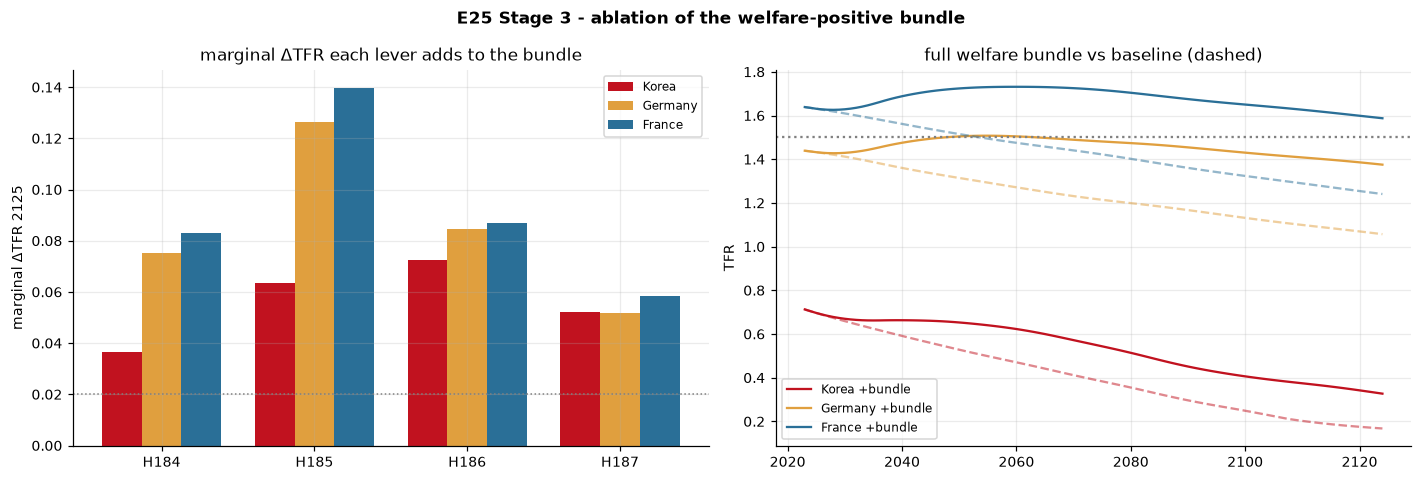

nb19_norms_ablation.png written

In [5]:
full={reg:seldon(reg,force_of(BUND)) for reg in TRIAD}
marg={L["id"]:{reg:full[reg]["dtfr"]-seldon(reg,force_of([x for x in BUND if x is not L]))["dtfr"] for reg in TRIAD} for L in BUND}
tbl=Table(title="E25 Stage 3 - marginal contribution in the welfare bundle (ΔTFR)",header_style="bold magenta")
for c in ["lever"]+TRIAD+["best"]: tbl.add_column(c)
for L in BUND:
    best=max(marg[L["id"]].values()); tbl.add_row(L["id"],*[f"{marg[L['id']][r]:+.3f}" for r in TRIAD],f"{best:+.3f}")
rprint(tbl)
fig,ax=plt.subplots(1,2,figsize=(13,4.4)); fig.suptitle("E25 Stage 3 - ablation of the welfare-positive bundle",fontweight="bold")
bl=[L["id"] for L in BUND]; x=np.arange(len(bl)); w=0.26
for k,r in enumerate(TRIAD):
    ax[0].bar(x+(k-1)*w,[marg[i][r] for i in bl],w,label=r,color=["#c1121f","#e09f3e","#2a6f97"][k])
ax[0].axhline(0.02,ls=":",c="grey",lw=1); ax[0].axhline(0,c="k",lw=0.6)
ax[0].set(title="marginal ΔTFR each lever adds to the bundle",xticks=x); ax[0].set_xticklabels(bl); ax[0].legend(fontsize=8); ax[0].set_ylabel("marginal ΔTFR 2125")
yr=np.arange(2023,2125)
for r,c in zip(TRIAD,["#c1121f","#e09f3e","#2a6f97"]):
    ax[1].plot(yr,BASE[r]["TFR"],ls="--",c=c,alpha=0.5); ax[1].plot(yr,full[r]["traj"]["TFR"],c=c,label=f"{r} +bundle")
ax[1].axhline(1.5,ls=":",c="grey"); ax[1].set(title="full welfare bundle vs baseline (dashed)",ylabel="TFR"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGS/"nb19_norms_ablation.png",bbox_inches="tight"); plt.show()
rprint("[green]nb19_norms_ablation.png written[/green]")

## Verdicts

Real verdicts, derived from the simulated standalone strength and the ablation marginals (not the leans).
A lever is SUPPORTED if it bends at its best region and carries a non-redundant marginal; PARTIAL if it is
real but weak, diffuse, or clamped by a coercion cost; REFUTED if it nets to ~0 or its backfire cancels it.

In [6]:
def bestsd(i): return max(sim[i][r]["dtfr"] for r in TRIAD)
def bestmk(i): return max(marg[i].values()) if i in marg else float("nan")
def vlabel(i,coercive=False,backfire=False):
    sd=bestsd(i); mk=bestmk(i) if i in marg else 0.0
    if backfire and sd<=0.012: return "REFUTED"
    if sd>=0.10 and (mk!=mk or mk>=0.04): return "PARTIAL" if coercive else "SUPPORTED"
    if sd>0.02 or (mk==mk and mk>0.02): return "PARTIAL"
    return "REFUTED"
V=[
 dict(id="E25-H182",claim="abortion restrictiveness graded to a total ban lifts fertility",
      evidence=f"standalone best {bestsd('H182'):+.3f}; the restrictiveness sweep peaks at an INTERIOR r*≈{r_star:.1f} - a total ban is dominated because leakage δ(r) and Romania-style reversion rise with severity; small, coercive, high autonomy cost",
      verdict=vlabel("H182",coercive=True)),
 dict(id="E25-H183",claim="penalising helpers closes the abortion leakage worth the backfire",
      evidence=f"standalone best {bestsd('H183'):+.3f} - lowering leakage (δ 0.55->0.30) is cancelled by the security/coupling chill it induces; the enforcement lever nets to ~0 with the highest coercion cost in the batch",
      verdict=vlabel("H183",backfire=True)),
 dict(id="E25-H184",claim="kin / grandparental support raises fertility (cooperative breeding)",
      evidence=f"standalone best {bestsd('H184'):+.3f}, bundle marginal best {bestmk('H184'):+.3f}; real cooperative-breeding channel (Sear-Mace) but a partial lever - proximity can be subsidised, kin density cannot be legislated",
      verdict=vlabel("H184")),
 dict(id="E25-H185",claim="in-kind childcare services beat equivalent cash",
      evidence=f"standalone best {bestsd('H185'):+.3f} ({[sim['H185'][r]['fate'] for r in TRIAD]}), bundle marginal best {bestmk('H185'):+.3f}; the durable Pbar+S in-kind geometry - the strongest welfare lever in the batch",
      verdict=vlabel("H185")),
 dict(id="E25-H186",claim="reversing social atomisation restores coupling",
      evidence=f"standalone best {bestsd('H186'):+.3f}, bundle marginal best {bestmk('H186'):+.3f}; a real coupling channel that helps the trap-limited basin but diffuse and high-leakage - a harbinger-grade nudge, not a heavy lever",
      verdict=vlabel("H186")),
 dict(id="E25-H187",claim="the bistable social norm is a pronatal lever",
      evidence=f"standalone best {bestsd('H187'):+.3f}, marginal best {bestmk('H187'):+.3f}; the MECHANISM is confirmed (tips + LOCKS with hysteresis) but as a pronatal lever it is weak on this triad - Korea is coupling-limited (norm barely moves TFR) and Germany is already untrapped; its real force is defensive/asymmetric - a modest STIGMA push tips Germany down by {BASE['Germany']['tfr']-g_stig['tfr']:.2f}",
      verdict=vlabel("H187")),
]
(REPORTS/"nb19_e25_verdicts.json").write_text(json.dumps(V,indent=2))
with open(REPORTS/"nb19_norms_table.csv","w",newline="") as f:
    w=csv.writer(f); w.writerow(["id","name","arm","cost","best_dTFR","best_region","marginal_best","verdict"])
    for L in LEV:
        i=L["id"]; br=max(TRIAD,key=lambda r:sim[i][r]["dtfr"]); mk=bestmk(i)
        vd=[v for v in V if v["id"]==f"E25-{i}"][0]["verdict"]
        w.writerow([i,L["name"],L["arm"],cost(L),round(bestsd(i),3),br,round(mk,3) if mk==mk else "-",vd])
tbl=Table(title="E25 verdicts",header_style="bold green")
for c in ["id","verdict","evidence"]: tbl.add_column(c,overflow="fold")
for v in V: tbl.add_row(v["id"],v["verdict"],v["evidence"])
rprint(tbl)
counts={}
for v in V: counts[v["verdict"]]=counts.get(v["verdict"],0)+1
rprint(Panel(f"E25 social norms + abortion, model-as-judge: {counts}. In-kind childcare (H185) is the load-bearing "
             "welfare lever; kin support and de-atomisation are real but partial; the abortion arm is small, coercive and "
             "dominated by an interior optimum (a total ban leaks and reverts), and penalising helpers nets to zero against its "
             "own backfire. The headline is H187: the norm is a genuine BISTABLE state - it tips and locks with hysteresis - but "
             "on this triad it is a weak pronatal lever and a dangerous vulnerability, since a modest stigma push tips an "
             "untrapped country down far more easily than a pronatal push lifts a trapped one. Campaign total -> 212.",
             title="[bold]batch E25[/bold]",border_style="green"))

                                                   E25 verdicts                                                    
┏━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ id       ┃ verdict   ┃ evidence                                                                                 ┃
┡━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ E25-H182 │ REFUTED   │ standalone best +0.001; the restrictiveness sweep peaks at an INTERIOR r*≈0.5 - a total  │
│          │           │ ban is dominated because leakage δ(r) and Romania-style reversion rise with severity;    │
│          │           │ small, coercive, high autonomy cost                                                      │
│ E25-H183 │ REFUTED   │ standalone best +0.001 - lowering leakage (δ 0.55->0.30) is cancelled by the             │
│          │           │ security/coupling chill it induces; the enforcement lever nets to ~0 with the highest    │
│          │           │ coercion cost in the batch                                                               │
│ E25-H184 │ PARTIAL   │ standalone best +0.074, bundle marginal best +0.083; real cooperative-breeding channel   │
│          │           │ (Sear-Mace) but a partial lever - proximity can be subsidised, kin density cannot be     │
│          │           │ legislated                                                                               │
│ E25-H185 │ SUPPORTED │ standalone best +0.127 (['holds', 'bends', 'bends']), bundle marginal best +0.140; the   │
│          │           │ durable Pbar+S in-kind geometry - the strongest welfare lever in the batch               │
│ E25-H186 │ PARTIAL   │ standalone best +0.077, bundle marginal best +0.087; a real coupling channel that helps  │
│          │           │ the trap-limited basin but diffuse and high-leakage - a harbinger-grade nudge, not a     │
│          │           │ heavy lever                                                                              │
│ E25-H187 │ PARTIAL   │ standalone best +0.049, marginal best +0.058; the MECHANISM is confirmed (tips + LOCKS   │
│          │           │ with hysteresis) but as a pronatal lever it is weak on this triad - Korea is             │
│          │           │ coupling-limited (norm barely moves TFR) and Germany is already untrapped; its real      │
│          │           │ force is defensive/asymmetric - a modest STIGMA push tips Germany down by 0.13           │
└──────────┴───────────┴──────────────────────────────────────────────────────────────────────────────────────────┘

╭─────────────────────────────────────────────────── batch E25 ───────────────────────────────────────────────────╮
│ E25 social norms + abortion, model-as-judge: {'REFUTED': 2, 'PARTIAL': 3, 'SUPPORTED': 1}. In-kind childcare    │
│ (H185) is the load-bearing welfare lever; kin support and de-atomisation are real but partial; the abortion arm │
│ is small, coercive and dominated by an interior optimum (a total ban leaks and reverts), and penalising helpers │
│ nets to zero against its own backfire. The headline is H187: the norm is a genuine BISTABLE state - it tips and │
│ locks with hysteresis - but on this triad it is a weak pronatal lever and a dangerous vulnerability, since a    │
│ modest stigma push tips an untrapped country down far more easily than a pronatal push lifts a trapped one.     │
│ Campaign total -> 212.                                                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯